# Example 05B: Run Ensemble Simulations

This notebook resumes the prepared siblings from notebook 05A and runs the expensive dynamic portion: step 10 input definition, step 11 SWMM simulation, and step 12 flow-component extraction.

## Setup

In [1]:
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import json
import os
import subprocess
import sys
import time

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "sewertris").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EXAMPLES_DIR = PROJECT_ROOT / "examples"
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import sewertris as sp

BASE_PROJECT_FILE = EXAMPLES_DIR / "output_example_2_project" / "sewertris_project.json"
ENSEMBLE_ROOT = EXAMPLES_DIR / "output_example_5_ensembles"
SCENARIO_NAME = "bwf_gwi_rdii"

base_project = sp.SewerTrisProject.load(BASE_PROJECT_FILE)
ENSEMBLE_ROOT.mkdir(parents=True, exist_ok=True)
print("Base project:", base_project.project_file)

Base project: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewertris_project.json


## Load Prepared Siblings

In [2]:
RUN_SIMULATIONS = True
USE_PARALLEL = True
MAX_WORKERS = 6

PREPARED_MANIFEST = ENSEMBLE_ROOT / "prepared_siblings_manifest.csv"
SIMULATION_MANIFEST = ENSEMBLE_ROOT / "simulation_manifest.csv"

prepared_manifest = pd.read_csv(PREPARED_MANIFEST)
prepared_specs = prepared_manifest[["ensemble", "realization", "project_file"]].to_dict("records")
for spec in prepared_specs:
    stem = f"simulate_{spec['ensemble']}_{int(spec['realization']):03d}"
    spec["progress_path"] = ENSEMBLE_ROOT / "_workers" / f"{stem}_progress.json"
display(prepared_manifest)

,ensemble,realization,project_file,flows_path,rerun_from,stop_after_step
0,drainage_shift_west,1,/Users/kevinblanco/Documents/Sewertris/example...,NaN,03_stochastic_tetris_completion,9
1,drainage_shift_west,2,/Users/kevinblanco/Documents/Sewertris/example...,NaN,03_stochastic_tetris_completion,9
2,drainage_shift_west,3,/Users/kevinblanco/Documents/Sewertris/example...,NaN,03_stochastic_tetris_completion,9
3,seed_only,1,/Users/kevinblanco/Documents/Sewertris/example...,NaN,03_stochastic_tetris_completion,9
4,seed_only,2,/Users/kevinblanco/Documents/Sewertris/example...,NaN,03_stochastic_tetris_completion,9
5,seed_only,3,/Users/kevinblanco/Documents/Sewertris/example...,NaN,03_stochastic_tetris_completion,9


## Parallel Simulation

Each worker loads one prepared sibling and resumes at step 10. Keeping this separate makes failed or slow SWMM runs easier to restart without rebuilding the physical model.

In [3]:
def json_ready(value):
    if isinstance(value, Path):
        return str(value.resolve())
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_ready(v) for v in value]
    return value


def run_worker_payload(payload, stem):
    worker_dir = ENSEMBLE_ROOT / "_workers"
    worker_dir.mkdir(parents=True, exist_ok=True)
    payload_path = worker_dir / f"{stem}.json"
    result_path = worker_dir / f"{stem}_result.json"
    payload_path.write_text(json.dumps(json_ready(payload), indent=2))

    env = os.environ.copy()
    env["PYTHONPATH"] = os.pathsep.join([str(SRC_DIR), env.get("PYTHONPATH", "")]).strip(os.pathsep)
    completed = subprocess.run(
        [
            sys.executable,
            "-m",
            "sewertris.ensemble",
            str(payload_path),
            "--result-file",
            str(result_path),
        ],
        cwd=PROJECT_ROOT,
        env=env,
        text=True,
        capture_output=True,
    )
    if completed.returncode != 0:
        raise RuntimeError(f"Worker failed for {stem}\nSTDOUT:\n{completed.stdout}\nSTDERR:\n{completed.stderr}")
    return json.loads(result_path.read_text())


def read_progress(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text())
    except json.JSONDecodeError:
        return None


def progress_label(spec):
    return f"{spec['ensemble']} run_{int(spec['realization']):03d}"


def print_active_progress(pending_specs, completed, successful, failed):
    total = completed + len(pending_specs)
    active = []
    for spec in pending_specs:
        event = read_progress(spec["progress_path"])
        if event is None:
            active.append(f"{progress_label(spec)}: queued")
        else:
            step = event.get("step", "starting")
            active.append(f"{progress_label(spec)}: {step}")
    preview = "; ".join(active[:6])
    if len(active) > 6:
        preview += f"; ... +{len(active) - 6} more"
    print(
        f"[progress] completed {completed}/{total} "
        f"(success={successful}, failed={failed}). Active: {preview}"
    )


def run_parallel(items, worker, max_workers, heartbeat_seconds=10):
    results = []
    successful = 0
    failed = 0
    last_heartbeat = 0

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(worker, item): item for item in items}
        pending = set(futures)

        while pending:
            finished = [future for future in pending if future.done()]
            if finished:
                for future in finished:
                    pending.remove(future)
                    spec = futures[future]
                    try:
                        result = future.result()
                    except Exception:
                        failed += 1
                        print(f"[failed] {progress_label(spec)}")
                        raise
                    else:
                        successful += 1
                        results.append(result)
                        event = read_progress(spec["progress_path"]) or {}
                        print(
                            f"[done] {progress_label(spec)} "
                            f"({successful}/{len(items)} successful) "
                            f"last_step={event.get('step', result.get('rerun_from'))}"
                        )
                continue

            now = time.time()
            if now - last_heartbeat >= heartbeat_seconds:
                pending_specs = [futures[future] for future in pending]
                print_active_progress(
                    pending_specs,
                    completed=len(items) - len(pending),
                    successful=successful,
                    failed=failed,
                )
                last_heartbeat = now
            time.sleep(1)

    return results


def run_simulation(spec):
    stem = f"simulate_{spec['ensemble']}_{int(spec['realization']):03d}"
    payload = {
        "mode": "simulation",
        "parent_project_file": BASE_PROJECT_FILE,
        "scenario_name": SCENARIO_NAME,
        "progress_path": spec["progress_path"],
        "spec": {key: value for key, value in spec.items() if key != "progress_path"},
    }
    return run_worker_payload(payload, stem)


if RUN_SIMULATIONS:
    if USE_PARALLEL:
        simulation_results = run_parallel(prepared_specs, run_simulation, MAX_WORKERS)
    else:
        simulation_results = [run_simulation(spec) for spec in prepared_specs]

    simulation_manifest = pd.DataFrame(simulation_results).sort_values(["ensemble", "realization"])
    simulation_manifest.to_csv(SIMULATION_MANIFEST, index=False)
    display(simulation_manifest)
else:
    print("Set RUN_SIMULATIONS = True to run the SWMM simulations.")

[progress] completed 0/6 (success=0, failed=0). Active: drainage_shift_west run_001: 12_flow_output_decomposition; drainage_shift_west run_003: 12_flow_output_decomposition; seed_only run_002: 12_flow_output_decomposition; drainage_shift_west run_002: 12_flow_output_decomposition; seed_only run_003: 12_flow_output_decomposition; seed_only run_001: 12_flow_output_decomposition
[progress] completed 0/6 (success=0, failed=0). Active: drainage_shift_west run_001: 11_epa_swmm_simulation; drainage_shift_west run_003: 11_epa_swmm_simulation; seed_only run_002: 11_epa_swmm_simulation; drainage_shift_west run_002: 11_epa_swmm_simulation; seed_only run_003: 11_epa_swmm_simulation; seed_only run_001: 11_epa_swmm_simulation
[progress] completed 0/6 (success=0, failed=0). Active: drainage_shift_west run_001: 11_epa_swmm_simulation; drainage_shift_west run_003: 11_epa_swmm_simulation; seed_only run_002: 11_epa_swmm_simulation; drainage_shift_west run_002: 11_epa_swmm_simulation; seed_only run_003: 1

,ensemble,realization,project_file,scenario_input,flows_path,rerun_from
0,drainage_shift_west,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model
4,drainage_shift_west,2,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model
2,drainage_shift_west,3,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model
1,seed_only,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model
3,seed_only,2,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model
5,seed_only,3,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model


## Analyze Results

In [4]:
if SIMULATION_MANIFEST.exists():
    simulation_manifest = pd.read_csv(SIMULATION_MANIFEST)
    simulation_manifest["flows_exists"] = simulation_manifest["flows_path"].map(lambda p: Path(p).exists())
    display(simulation_manifest)
else:
    print("No simulation manifest yet.")

,ensemble,realization,project_file,scenario_input,flows_path,rerun_from,flows_exists
0,drainage_shift_west,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,True
1,drainage_shift_west,2,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,True
2,drainage_shift_west,3,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,True
3,seed_only,1,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,True
4,seed_only,2,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,True
5,seed_only,3,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,/Users/kevinblanco/Documents/Sewertris/example...,10_dynamic_flow_input_definition_base_model,True


## Example Single-Member Comparison

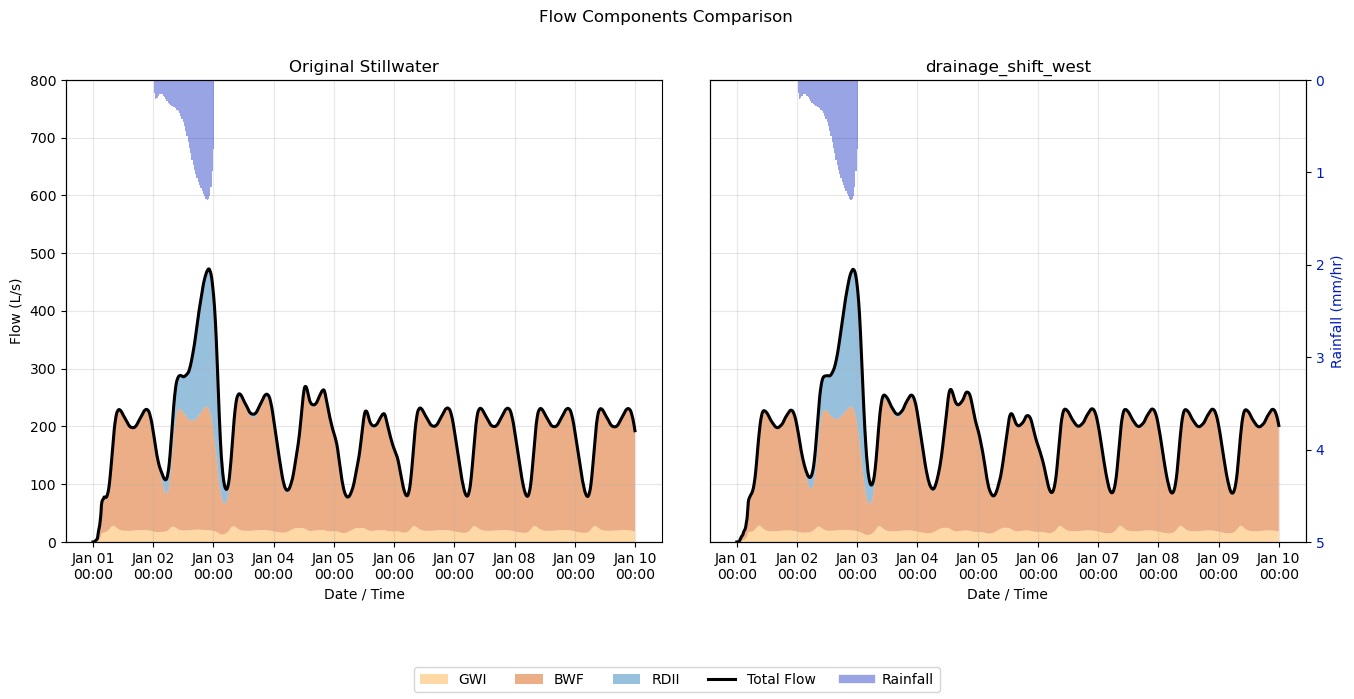

In [7]:
rainfall_data=[
    ('1/2/2025', '00:00', 0.0), ('1/2/2025', '00:30', 0.138), ('1/2/2025', '01:00', 0.201),
    ('1/2/2025', '01:30', 0.195), ('1/2/2025', '02:00', 0.171), ('1/2/2025', '02:30', 0.153),
    ('1/2/2025', '03:00', 0.147), ('1/2/2025', '03:30', 0.156), ('1/2/2025', '04:00', 0.171),
    ('1/2/2025', '04:30', 0.189), ('1/2/2025', '05:00', 0.21), ('1/2/2025', '05:30', 0.228),
    ('1/2/2025', '06:00', 0.246), ('1/2/2025', '06:30', 0.258), ('1/2/2025', '07:00', 0.27),
    ('1/2/2025', '07:30', 0.279), ('1/2/2025', '08:00', 0.288), ('1/2/2025', '08:30', 0.297),
    ('1/2/2025', '09:00', 0.309), ('1/2/2025', '09:30', 0.321), ('1/2/2025', '10:00', 0.339),
    ('1/2/2025', '10:30', 0.357), ('1/2/2025', '11:00', 0.387), ('1/2/2025', '11:30', 0.42),
    ('1/2/2025', '12:00', 0.456), ('1/2/2025', '12:30', 0.501), ('1/2/2025', '13:00', 0.555),
    ('1/2/2025', '13:30', 0.609), ('1/2/2025', '14:00', 0.669), ('1/2/2025', '14:30', 0.732),
    ('1/2/2025', '15:00', 0.795), ('1/2/2025', '15:30', 0.861), ('1/2/2025', '16:00', 0.918),
    ('1/2/2025', '16:30', 0.972), ('1/2/2025', '17:00', 1.023), ('1/2/2025', '17:30', 1.065),
    ('1/2/2025', '18:00', 1.104), ('1/2/2025', '18:30', 1.137), ('1/2/2025', '19:00', 1.167),
    ('1/2/2025', '19:30', 1.197), ('1/2/2025', '20:00', 1.23), ('1/2/2025', '20:30', 1.26),
    ('1/2/2025', '21:00', 1.287), ('1/2/2025', '21:30', 1.302), ('1/2/2025', '22:00', 1.293),
    ('1/2/2025', '22:30', 1.251), ('1/2/2025', '23:00', 1.155), ('1/2/2025', '23:30', 0.984),
    ('1/3/2025', '00:00', 0.747), ('1/3/2025', '00:30', 0.0), ('1/3/2025', '01:00', 0.0),
]

if SIMULATION_MANIFEST.exists() and not simulation_manifest.empty:
    first = simulation_manifest.iloc[0]
    first_project = sp.SewerTrisProject.load(first["project_file"])
    options = base_project.step_parameters("10_dynamic_flow_input_definition_base_model").get("options_dict", {})
    start = f"{options.get('START_DATE', '01/01/1990')} {options.get('START_TIME', '00:00:00')}"
    end = f"{options.get('END_DATE', '01/10/1990')} {options.get('END_TIME', '00:00:00')}"

    sp.plot_two_models(
        "flow_components",
        base_project,
        first_project,
        labels=("Original Stillwater", first["ensemble"]),
        scenario_name=SCENARIO_NAME,
        start=start,
        end=end,
        rain=rainfall_data,
        flow_min=0,
        flow_max=800,
        rain_min=0,
        rain_max=5
    )
else:
    print("Run the simulations first, then compare a completed member.")

In [8]:
import os

# Your code here
# ...

os.system('afplay /System/Library/Sounds/Hero.aiff')
os.system('say "Kevin, your simulation has finished."')

0